In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df = pd.read_csv("/content/ai4i2020_extended_manufacturing.csv.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Material Delay (min),Workforce Constraint (%),Quality Issue Rate (%),Shift Schedule,Production Backlog (units),Issue Notes
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,5.0,0.22,Evening,52,Routine monitoring completed with no major issues
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,8.4,2.04,Morning,37,Minor operational variation observed but produ...
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,7.9,0.85,Night,49,Routine monitoring completed with no major issues
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,46,4.7,1.93,Evening,65,Minor delay reported in material replenishment.
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,6.2,1.61,Morning,62,Routine monitoring completed with no major issues


In [ ]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Material Delay (min)', 'Workforce Constraint (%)', 'Quality Issue Rate (%)', 'Shift Schedule', 'Production Backlog (units)', 'Issue Notes']


In [ ]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

target = "Machine failure"

X = df[features].copy()
y = df[target].copy()

print(X.shape)
print(y.shape)

(10000, 6)
(10000,)


In [ ]:
X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

print(X.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_L  Type_M  
0         42.8                0   False    True  
1         46.3                3    True   False  
2         49.4                5    True   False  
3         39.5                7    True   False  
4         40.0                9    True   False  


In [ ]:
print("Class Counts:")
print(y.value_counts())

print("\nClass Percentage:")
print(y.value_counts(normalize=True) * 100)

Class Counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Class Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 7)
Testing data: (2000, 7)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [ ]:
gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [ ]:
gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
results = []

models_data = [
    ("Logistic Regression", lr_pred, lr_prob),
    ("Random Forest", rf_pred, rf_prob),
    ("Gradient Boosting", gb_pred, gb_prob)
]

for name, pred, prob in models_data:

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            prob
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.9835,0.753623,0.764706,0.759124,0.967894
1,Random Forest,0.9805,0.914286,0.470588,0.621359,0.961899
0,Logistic Regression,0.8245,0.141772,0.823529,0.241901,0.906954


In [ ]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

[[1593  339]
 [  12   56]]


In [ ]:
print("RANDOM FOREST")
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.47      0.62        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000

[[1929    3]
 [  36   32]]


In [ ]:
print("GRADIENT BOOSTING")
print(classification_report(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))

GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.76      0.76        68

    accuracy                           0.98      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000

[[1915   17]
 [  16   52]]


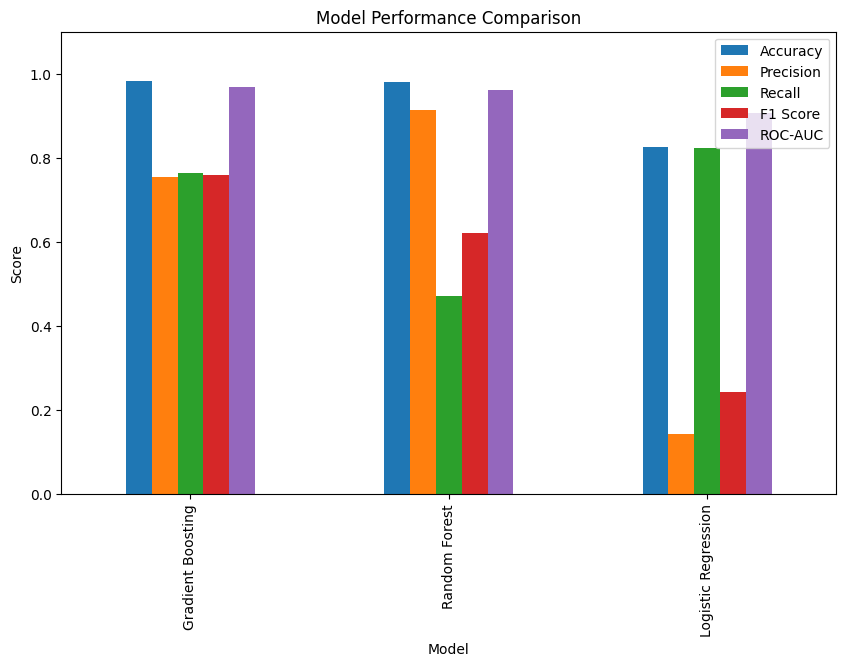

In [ ]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.show()

In [ ]:
import joblib

# Save model
joblib.dump(gb_model, "gradient_boosting_model.pkl")

# Save feature column names
joblib.dump(list(X.columns), "model_features.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("gradient_boosting_model.pkl")
files.download("model_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def calculate_disruption_risk(
    machine_failure_probability,
    material_delay,
    workforce_constraint,
    quality_issue_rate,
    production_backlog
):


    machine_risk = machine_failure_probability * 100

    material_risk = min(
        (material_delay / 240) * 100,
        100
    )

    workforce_risk = min(
        (workforce_constraint / 40) * 100,
        100
    )

    quality_risk = min(
        (quality_issue_rate / 25) * 100,
        100
    )

    backlog_risk = min(
        (production_backlog / 500) * 100,
        100
    )

    overall_risk = (
        0.40 * machine_risk +
        0.20 * material_risk +
        0.15 * workforce_risk +
        0.15 * quality_risk +
        0.10 * backlog_risk
    )

    return round(overall_risk, 2)

In [ ]:
def get_risk_level(score):

    if score <= 30:
        return "LOW"

    elif score <= 60:
        return "MEDIUM"

    elif score <= 80:
        return "HIGH"

    else:
        return "CRITICAL"

In [ ]:
def get_recommendations(
    machine_probability,
    material_delay,
    workforce_constraint,
    quality_issue_rate,
    production_backlog
):

    recommendations = []

    if machine_probability >= 0.50:
        recommendations.append(
            "Schedule immediate machine inspection and preventive maintenance."
        )

    if material_delay >= 60:
        recommendations.append(
            "Contact supplier and arrange alternative material availability."
        )

    if workforce_constraint >= 15:
        recommendations.append(
            "Reallocate workforce or arrange additional shift support."
        )

    if quality_issue_rate >= 5:
        recommendations.append(
            "Perform immediate quality inspection and process calibration."
        )

    if production_backlog >= 150:
        recommendations.append(
            "Prioritize critical orders and rebalance production capacity."
        )

    if not recommendations:
        recommendations.append(
            "Continue normal monitoring and preventive maintenance."
        )

    return recommendations

In [ ]:
def get_root_causes(
    machine_probability,
    material_delay,
    workforce_constraint,
    quality_issue_rate,
    production_backlog
):

    causes = []

    if machine_probability >= 0.50:
        causes.append(
            f"High machine failure probability ({machine_probability*100:.1f}%)"
        )

    if material_delay >= 60:
        causes.append(
            f"Material delay of {material_delay} minutes"
        )

    if workforce_constraint >= 15:
        causes.append(
            f"Workforce shortage of {workforce_constraint}%"
        )

    if quality_issue_rate >= 5:
        causes.append(
            f"High quality issue rate ({quality_issue_rate}%)"
        )

    if production_backlog >= 150:
        causes.append(
            f"High production backlog ({production_backlog} units)"
        )

    if not causes:
        causes.append("No significant disruption factors detected")

    return causes

In [ ]:
def analyze_manufacturing_risk(input_data):

    # Create DataFrame for ML prediction
    input_df = pd.DataFrame([input_data])

    # Select ML features
    ml_features = [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]

    ml_input = input_df[ml_features].copy()

    # Convert Type
    ml_input = pd.get_dummies(
        ml_input,
        columns=["Type"],
        drop_first=True
    )

    # Ensure same columns as training
    ml_input = ml_input.reindex(
        columns=X.columns,
        fill_value=0
    )

    # ML prediction
    machine_probability = gb_model.predict_proba(
        ml_input
    )[0][1]

    # Calculate overall disruption risk
    overall_risk = calculate_disruption_risk(
        machine_probability,
        input_data["Material Delay (min)"],
        input_data["Workforce Constraint (%)"],
        input_data["Quality Issue Rate (%)"],
        input_data["Production Backlog (units)"]
    )

    # Risk level
    risk_level = get_risk_level(overall_risk)

    # Root causes
    causes = get_root_causes(
        machine_probability,
        input_data["Material Delay (min)"],
        input_data["Workforce Constraint (%)"],
        input_data["Quality Issue Rate (%)"],
        input_data["Production Backlog (units)"]
    )

    # Recommendations
    recommendations = get_recommendations(
        machine_probability,
        input_data["Material Delay (min)"],
        input_data["Workforce Constraint (%)"],
        input_data["Quality Issue Rate (%)"],
        input_data["Production Backlog (units)"]
    )

    priority_score = calculate_priority_score(
    overall_risk,
    input_data["Production Backlog (units)"]
)

    return {
        "machine_failure_probability":
            round(machine_probability * 100, 2),

        "overall_disruption_risk":
            overall_risk,

        "risk_level":
            risk_level,

        "root_causes":
            causes,

        "recommended_actions":
            recommendations,
        "priority_score": priority_score
    }

In [ ]:
sample = df.iloc[210]

input_data = {

    "Type": sample["Type"],

    "Air temperature [K]":
        sample["Air temperature [K]"],

    "Process temperature [K]":
        sample["Process temperature [K]"],

    "Rotational speed [rpm]":
        sample["Rotational speed [rpm]"],

    "Torque [Nm]":
        sample["Torque [Nm]"],

    "Tool wear [min]":
        sample["Tool wear [min]"],

    "Material Delay (min)":
        sample["Material Delay (min)"],

    "Workforce Constraint (%)":
        sample["Workforce Constraint (%)"],

    "Quality Issue Rate (%)":
        sample["Quality Issue Rate (%)"],

    "Production Backlog (units)":
        sample["Production Backlog (units)"]
}

In [ ]:
result = analyze_manufacturing_risk(input_data)

result

{'machine_failure_probability': np.float64(0.0),
 'overall_disruption_risk': np.float64(4.88),
 'risk_level': 'LOW',
 'root_causes': ['No significant disruption factors detected'],
 'recommended_actions': ['Continue normal monitoring and preventive maintenance.'],
 'priority_score': np.float64(7.92)}

In [ ]:
def calculate_priority_score(overall_risk, production_backlog):

    impact_score = min(
        (production_backlog / 500) * 100,
        100
    )

    priority_score = (
        0.7 * overall_risk +
        0.3 * impact_score
    )

    return round(priority_score, 2)